In [2]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

from ml.training import train_model, evaluate_model
from utils.plots import (
    plot_distribution,
    plot_roc,
    plot_confusion_matrix,
    plot_feature_importance,
    plot_discrimination_threshold,
    plot_threshold_tradeoff,
)
from ml.mskcc import mskcc_predict
from utils.tests import delong_roc_test, hanley_mcneil_test, bootstrap_auc_ci


pd.set_option("display.max_columns", None)

In [3]:
df_train = pd.read_csv("../data/train.csv")
df_test = pd.read_csv("../data/test.csv")
df_train["Bx ISUP Grade"] = df_train[["Bx ISUP L", "Bx ISUP R"]].max(axis=1)
df_test["Bx ISUP Grade"] = df_test[["Bx ISUP L", "Bx ISUP R"]].max(axis=1)
df_train.head()

,szpital,ID,wiek,PSA,data mri,data operacji,PSA density,iT,DRE,MRI prostate volume,MRI PIRADS,MRI EPE,MRI EPE L,MRI EPE P,MRI SVI,MRI SVI L,MRI SVI P,MRI lesion size,Bx ISUP L,Bx max % L,Bx wycinki L CEL,Bx wycinki L REG,Bx wycinki L SYS,Bx wycinki L,Bx ISUP R,Bx max % R,Bx wycinki R CEL,Bx wycinki R REG,Bx wycinki R SYS,Bx wycinki R,RP ISUP,RP ISUP R,RP ISUP L,RP SM+,RP N+,RP EPE,RP EPE strona,RP EPE L,RP EPE P,RP SVI,RP SVI strona,RP SVI L,RP SVI P,RP TNM,Bx ISUP Grade
0,Otwock,a727,63.0,5.10,2019-12-01,2020-01-01,NaN,2b,NaN,NaN,5.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,3.0,80.0,NaN,NaN,5na5,NaN,0.0,0.0,NaN,NaN,0,NaN,3.0,3.0,3.0,0.0,0.0,1.0,NaN,1,0,0.0,NaN,0.0,0.0,3a,3.0
1,Otwock,a236,69.0,5.37,2020-03-01,2020-05-01,0.179000,2c,NaN,30.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,0.0,0.0,NaN,NaN,0,NaN,2.0,NaN,NaN,NaN,2na5,NaN,3.0,3.0,2.0,0.0,0.0,0.0,NaN,0,0,0.0,NaN,0.0,0.0,2c,2.0
2,Otwock,a536,64.0,7.40,2019-09-01,2020-07-01,0.211429,2c,NaN,35.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,2.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,3.0,3.0,3.0,0.0,0.0,0.0,NaN,0,0,0.0,NaN,0.0,0.0,2b,2.0
3,Szwajcary,240,63.0,5.90,NaN,NaN,0.236000,3a,1.0,25.0,NaN,1.0,1.0,1.0,NaN,NaN,NaN,15.0,3.0,1.0,NaN,NaN,NaN,NaN,3.0,1.0,NaN,NaN,NaN,NaN,3.0,NaN,NaN,0.0,0.0,1.0,P,0,1,0.0,NaN,NaN,NaN,3a,3.0
4,Otwock,a737,73.0,97.00,NaN,2017-04-24,2.694444,3b,1.0,36.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,33.0,4.0,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,4.0,4.0,4.0,1.0,1.0,1.0,NaN,1,1,1.0,NaN,1.0,1.0,3b,4.0


In [4]:
df_test.dropna(subset=["RP EPE"], inplace=True)

In [5]:
numerical_cols = ["wiek", "PSA", "PSA density", "MRI prostate volume", "MRI lesion size"]
categorical_cols = ["MRI PIRADS", "MRI EPE", "MRI SVI", "Bx ISUP Grade"]

# EPE RP

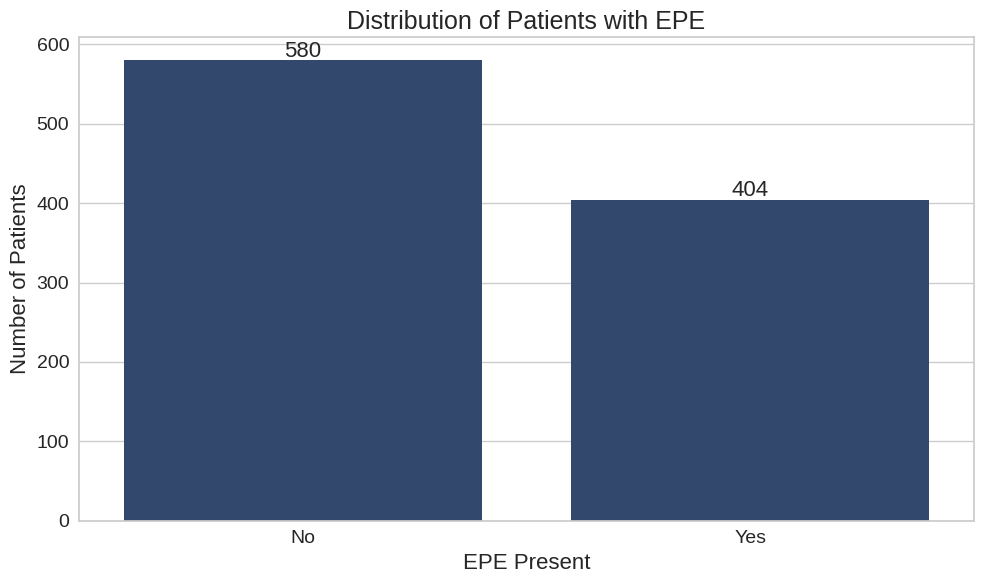

In [6]:
plot_distribution(df_train, "RP EPE", "Distribution of Patients with EPE", "EPE Present")

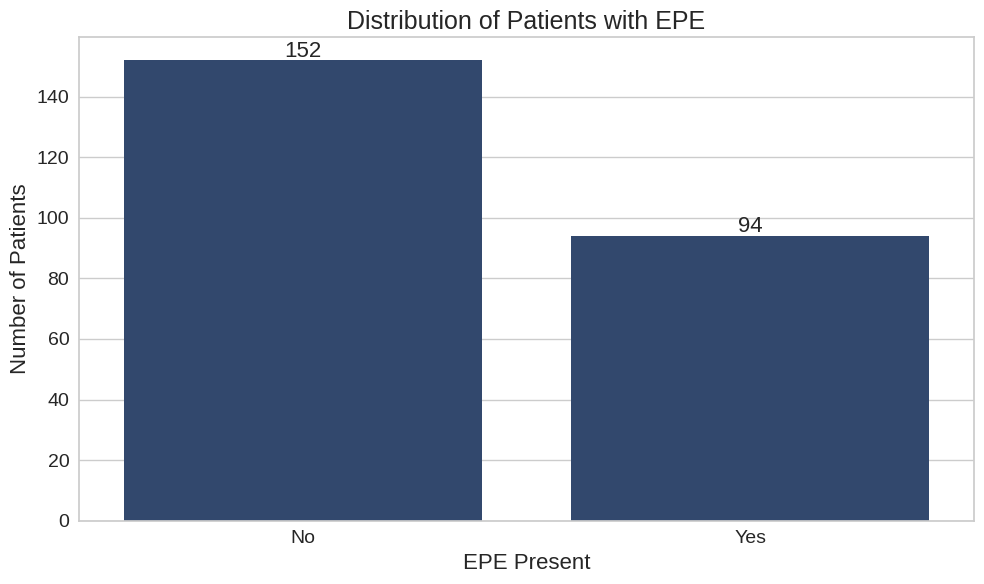

In [7]:
plot_distribution(df_test, "RP EPE", "Distribution of Patients with EPE", "EPE Present")

Tuning hyperparameters...



Best hyperparameters: {'classifier__learning_rate': 0.05, 'classifier__n_estimators': 200}
Best roc_auc score: 0.6690167378113313

Model hyperparameters after tuning: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 200, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 2, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 

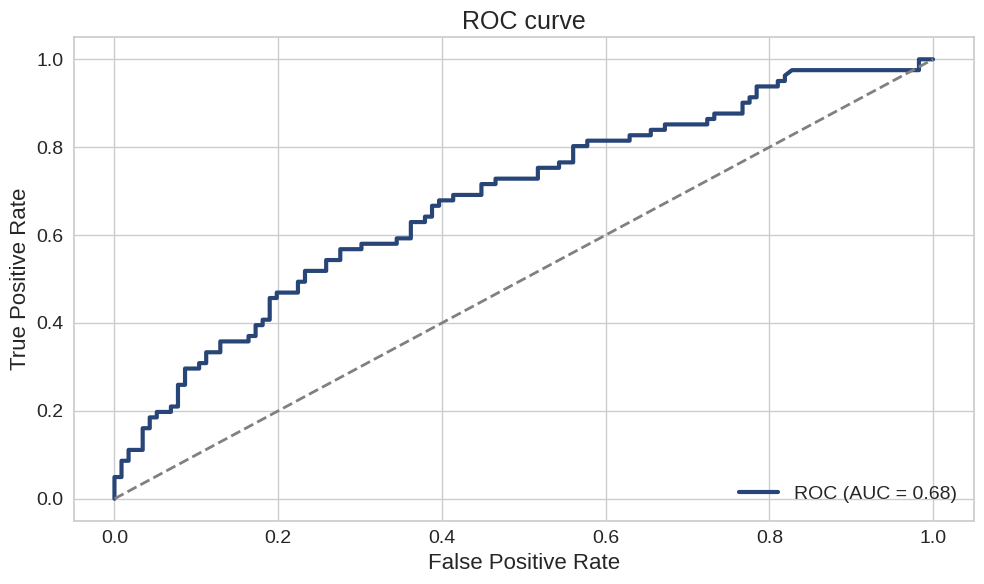

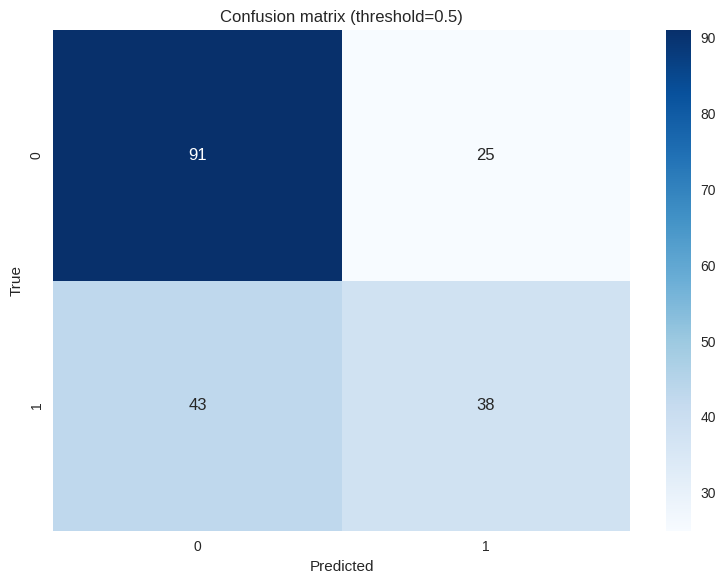

Sensitivity: 0.4691
Specificity: 0.7845
Accuracy: 0.6548
Preparation of a new explainer is initiated

  -> data              : 984 rows 9 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 984 values
  -> model_class       : xgboost.sklearn.XGBClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x73662e369f30> will be used (default)
  -> predict function  : Accepts only pandas.DataFrame, numpy.ndarray causes problems.
  -> predicted values  : min = 0.00936, mean = 0.388, max = 0.992
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.692, mean = 0.0227, max = 0.903
  -> model_info        : package sklearn

A new explainer has been created!


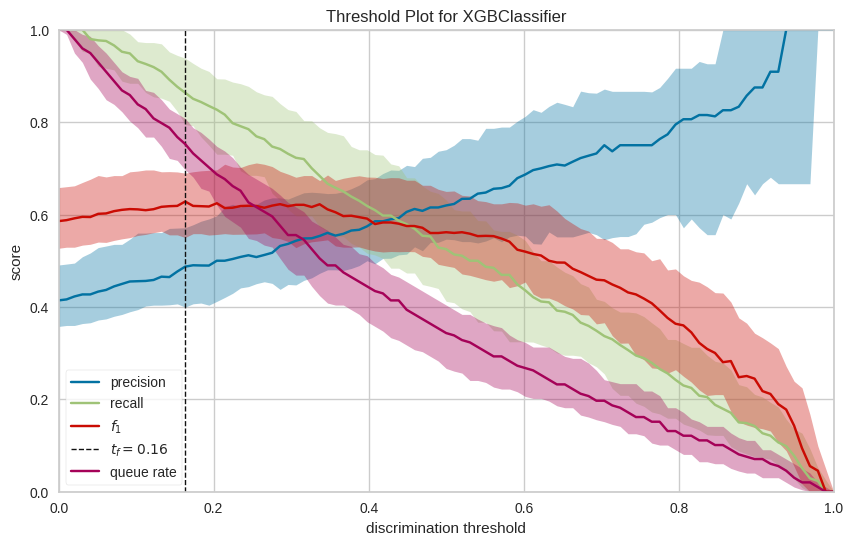

Evaluation results:
ROC AUC score: 0.6854003359462486
Results on the test set:



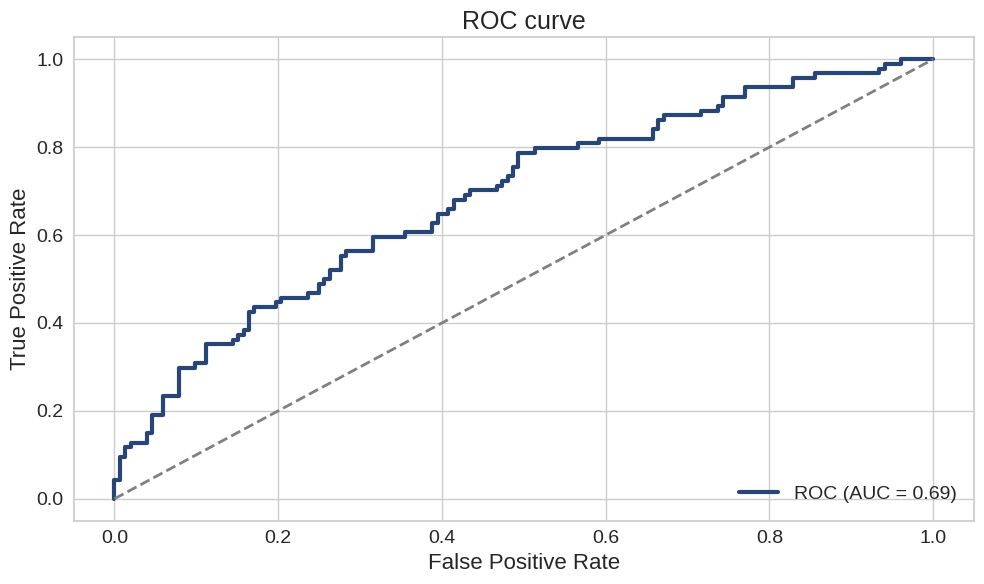

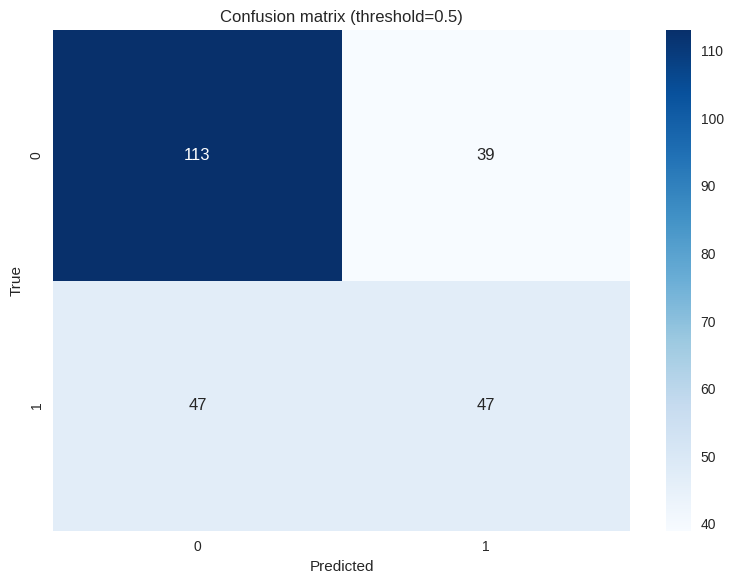

Sensitivity: 0.5000
Specificity: 0.7434
Accuracy: 0.6504
Preparation of a new explainer is initiated

  -> data              : 984 rows 9 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 984 values
  -> model_class       : xgboost.sklearn.XGBClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x73662e369f30> will be used (default)
  -> predict function  : Accepts only pandas.DataFrame, numpy.ndarray causes problems.
  -> predicted values  : min = 0.00936, mean = 0.388, max = 0.992
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.692, mean = 0.0227, max = 0.903
  -> model_info        : package sklearn

A new explainer has been created!


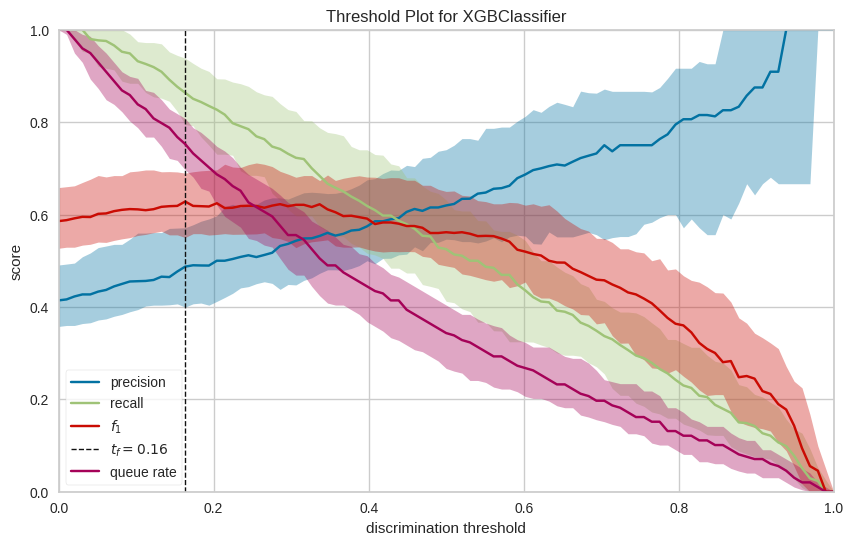

In [8]:
X_train = df_train[numerical_cols + categorical_cols]
y_train = df_train["RP EPE"]
X_test = df_test[numerical_cols + categorical_cols]
y_test = df_test["RP EPE"]


param_grid = {
    "classifier__learning_rate": [0.05, 0.1, 0.2],
    "classifier__n_estimators": [200, 400, 800],
    # "classifier__max_depth": [3, 6, 9],
    # "classifier__subsample": [0.8, 0.9, 1.0],
    # "classifier__colsample_bytree": [0.8, 0.9, 1.0],
    # "classifier__gamma": [0, 0.1, 0.2],
}

model = XGBClassifier(random_state=2)

train_res = train_model(
    model,
    X_train,
    y_train,
    numerical_cols,
    categorical_cols,
    n_folds=5,
    tune_params=True,
    param_grid=param_grid,
    tuning_scoring="roc_auc",
    tuning_test_size=0.2,
)

untrained_model = model.set_params(**train_res.best_params)

print("Results on the training set:\n")
plot_roc(train_res.fp_rate, train_res.tp_rate, train_res.roc_auc)
plot_confusion_matrix(train_res.y_true, train_res.y_pred)
plot_feature_importance(train_res.pipeline, X_train, y_train, title="Feature Importance for EPE RP Prediction")
plot_discrimination_threshold(untrained_model, X_train, y_train)

eval_res = evaluate_model(
    train_res.fully_trained_pipeline,
    X_test,
    y_test
)

untrained_model = model.set_params(**train_res.best_params)

print("Results on the test set:\n")
plot_roc(eval_res.fp_rate, eval_res.tp_rate, eval_res.roc_auc)
plot_confusion_matrix(eval_res.y_true, eval_res.y_pred)
plot_feature_importance(train_res.pipeline, X_train, y_train, title="Feature Importance for EPE RP Prediction")
plot_discrimination_threshold(untrained_model, X_train, y_train)